
# Optimisation results analysis
We will conduct a turbine-level analysis to understand how each of the optimisers work.

The case study used is Horns Rev 1.

In [8]:
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import os
import sys
import pandas as pd

BASELINE_HR1_POWER = 63.492160278290314  # megawatts of unyawed HR1
KEYS = ["best_yaw", "per_case_power_MW", "wind_dir_deg", "wind_speed", "weights"]

### Load the necessary .npz files


In [18]:
# Serial-Refine
sr_data = np.load(rf".\yaw_serial_hr1\20260309_172931\arrays.npz")

# SLSQP
slsqp_data = np.load(rf".\yaw_slsqp_hr1\20260309_173450\arrays.npz")

In [45]:
sr_data = {key: sr_data[key] for key in KEYS}
slsqp_data = {key: slsqp_data[key] for key in KEYS}

# Convert degrees to radians
sr_data['best_yaw'] = np.rad2deg(sr_data['best_yaw'])
slsqp_data['best_yaw'] = np.rad2deg(slsqp_data['best_yaw'])

sr_yaw = sr_data['best_yaw']
slsqp_yaw = slsqp_data['best_yaw']
sr_opt_power = sr_data['per_case_power_MW'][0]
slsqp_opt_power = slsqp_data['per_case_power_MW'][0]

## We can use FLORIS to plot wind turbine yaw angles

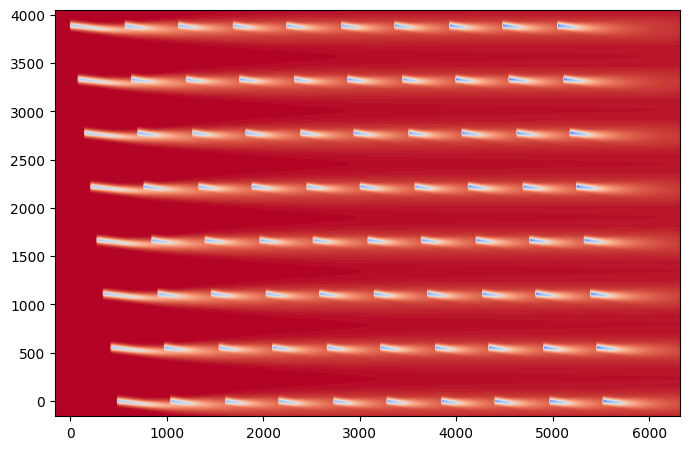

In [38]:
import floris.flow_visualization as flowviz
import floris.layout_visualization as layout_viz
from floris import FlorisModel
import yaml

def loader_with_include(path):
    """Custom YAML loader to support the !include tag."""
    class IncludeLoader(yaml.SafeLoader):
        def __init__(self, stream):
            self._root = os.path.split(stream.name)[0]
            super(IncludeLoader, self).__init__(stream)

    def construct_include(loader, node):
        filename = os.path.join(loader._root, loader.construct_scalar(node))
        with open(filename, 'r') as f:
            return yaml.load(f, IncludeLoader)

    yaml.add_constructor('!include', construct_include, IncludeLoader)
    return IncludeLoader

hr1_yaml = rf"..\data\horn\gch.yaml"
with open(hr1_yaml, 'r') as f:
    hr1_params = yaml.load(f, loader_with_include(hr1_yaml))

lx = hr1_params['farm']['layout_x']
ly = hr1_params['farm']['layout_y']

plt.style.use('default')

def plot_yaw_angles(yaw_angles: np.ndarray):
    fmodel = FlorisModel(hr1_yaml)
    fmodel.set(yaw_angles=yaw_angles)
    fmodel.run()

    fig, ax = plt.subplots(figsize=(7, 6))

    horizontal_plane = fmodel.calculate_horizontal_plane(height=90.0, x_resolution=400, y_resolution=400)
    flow = flowviz.visualize_cut_plane(horizontal_plane,ax=ax, levels=150)

    plt.tight_layout()
    plt.show()

plot_yaw_angles(sr_yaw)

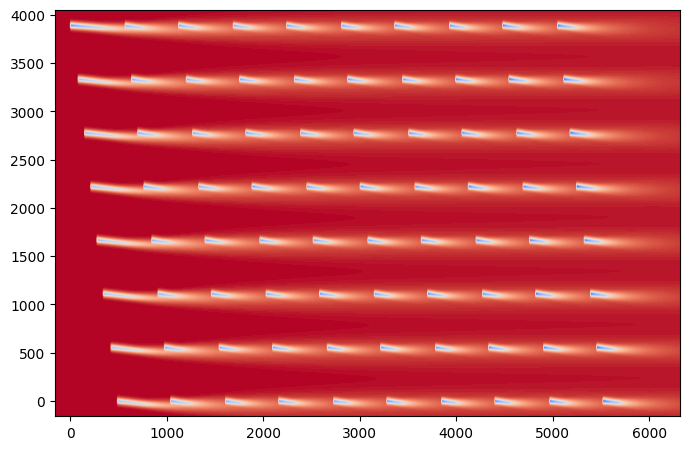

In [39]:
plot_yaw_angles(slsqp_yaw)